In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error,r2_score ,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [2]:
from google.colab import files
data=files.upload()

Saving CAR DETAILS FROM CAR DEKHO (1).csv to CAR DETAILS FROM CAR DEKHO (1).csv


In [3]:
df1=pd.read_csv('CAR DETAILS FROM CAR DEKHO (1).csv')

`preprocessing`

`error`
- outlier in 1312 as km driven is 1 and is owned by 2 owner
- outlier in price
- standarize
- transformation

In [4]:
df1.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
df1.shape

(4340, 8)

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [7]:
df1.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [8]:
df1.describe(include=object)

,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


In [9]:


df1[df1['km_driven']==1]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1312,Mahindra Quanto C6,2014,250000,1,Diesel,Individual,Manual,Second Owner


In [10]:
df1.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [11]:
#checking duplicates
df1.duplicated().sum()
df1[df1.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
13,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
14,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
15,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
16,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
17,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4307,Mahindra Xylo H4,2019,599000,15000,Diesel,Individual,Manual,Third Owner
4308,Maruti Alto 800 LXI,2018,200000,35000,Petrol,Individual,Manual,First Owner
4309,Datsun GO Plus T,2017,350000,10171,Petrol,Dealer,Manual,First Owner
4310,Renault Duster 110PS Diesel RxL,2015,465000,41123,Diesel,Dealer,Manual,First Owner


In [12]:
#dropping duplicates
df1=df1.drop_duplicates(keep='first')

In [13]:
#checking if duplicated drop
df1.duplicated().sum()

np.int64(0)

In [14]:
df1.shape

(3577, 8)

In [15]:
#checking null value
df1.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [16]:
#checking and pointing outlier
def check_outliers(dataframe, column_name):
    # 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
    q1 = dataframe[column_name].quantile(0.25)
    q3 = dataframe[column_name].quantile(0.75)

    # 2. Compute the Interquartile Range (IQR)
    iqr = q3 - q1

    # 3. Define the fences (boundaries)
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    # 4. Count how many data points fall outside the fences
    min_outliers = dataframe[dataframe[column_name] < lower_fence].shape[0]
    max_outliers = dataframe[dataframe[column_name] > upper_fence].shape[0]

    # 5. Display the diagnostic report
    print(f"📊 --- Outlier Report for '{column_name}' ---")
    print(f"Lower Fence (Min Limit): {lower_fence:.2f} | Found: {min_outliers} minimum outliers")
    print(f"Upper Fence (Max Limit): {upper_fence:.2f} | Found: {max_outliers} maximum outliers")
    print(f"Total Outliers in Column: {min_outliers + max_outliers}\n")
    # Check your Total Spend column
check_outliers(df1, 'selling_price')

# Check your Days Since Last Purchase column
check_outliers(df1, 'km_driven')
check_outliers(df1, 'year')


📊 --- Outlier Report for 'selling_price' ---
Lower Fence (Min Limit): -400000.00 | Found: 0 minimum outliers
Upper Fence (Max Limit): 1200000.00 | Found: 170 maximum outliers
Total Outliers in Column: 170

📊 --- Outlier Report for 'km_driven' ---
Lower Fence (Min Limit): -45000.00 | Found: 0 minimum outliers
Upper Fence (Max Limit): 171000.00 | Found: 106 maximum outliers
Total Outliers in Column: 106

📊 --- Outlier Report for 'year' ---
Lower Fence (Min Limit): 2001.00 | Found: 37 minimum outliers
Upper Fence (Max Limit): 2025.00 | Found: 0 maximum outliers
Total Outliers in Column: 37



In [17]:
#creating a copy dataframe
df_neat=df1.copy()

In [18]:
#treating outlier by winsorization mehtod
for col in ['selling_price', 'km_driven','year']:
    lower_limit = df_neat[col].quantile(0.01) # Bottom 1% cutoff
    upper_limit = df_neat[col].quantile(0.99) # Top 99% cutoff

    # Clip/Cap the values to these boundaries
    df_neat[col] = df_neat[col].clip(lower_limit, upper_limit)

In [19]:
#checking
print("Old Max Price:", df1['selling_price'].max())
print("New Capped Max Price:", df_neat['selling_price'].max())
print("=====================")
print("Old Max Price:", df1['km_driven'].max())
print("New Capped Max Price:", df_neat['km_driven'].max())
print("++++++++=========================")
print("Old Max Price:", df1['year'].max())
print("New Capped Max Price:", df_neat['year'].max())
print("====================================")
print("Old Max Price:", df1['year'].min())
print("New Capped Max Price:", df_neat['year'].min())

Old Max Price: 8900000
New Capped Max Price: 2675000.0
Old Max Price: 806599
New Capped Max Price: 223158.39999999985
++++++++=========================
Old Max Price: 2020
New Capped Max Price: 2020
Old Max Price: 1992
New Capped Max Price: 2000


# `eda`

<Axes: xlabel='km_driven', ylabel='selling_price'>

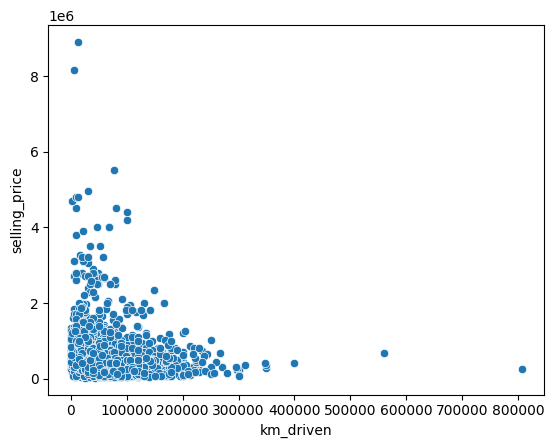

In [20]:


sns.scatterplot(data=df1,x='km_driven',y='selling_price')

<Axes: xlabel='km_driven', ylabel='selling_price'>

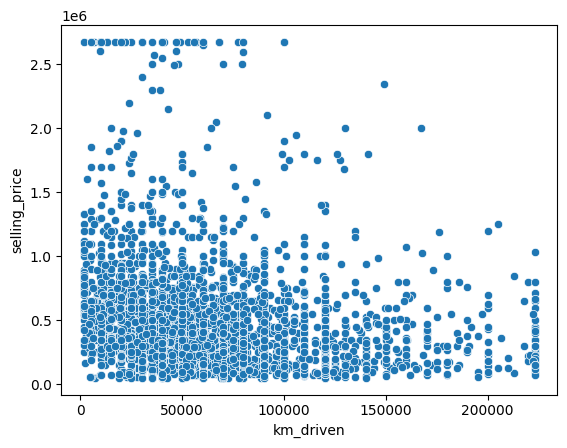

In [21]:

sns.scatterplot(data=df_neat,x='km_driven',y='selling_price')

<Axes: xlabel='selling_price', ylabel='year'>

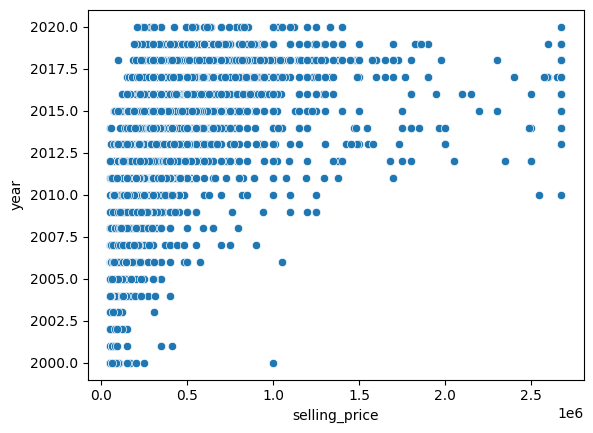

In [ ]:
sns.scatterplot(data=df_neat,x='selling_price',y='year')

<Axes: xlabel='seller_type', ylabel='year'>

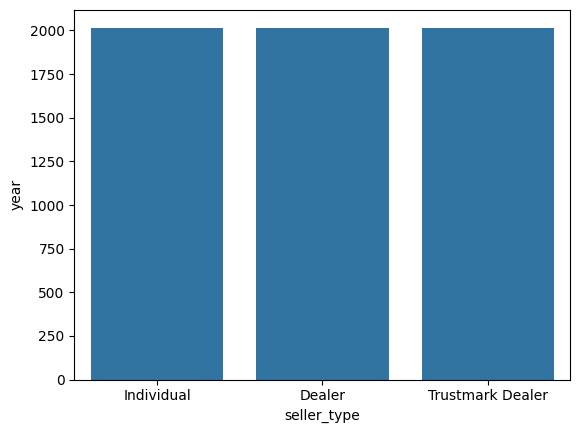

In [ ]:
sns.barplot(data=df_neat,x='seller_type',y='year')

<Axes: xlabel='year', ylabel='owner'>

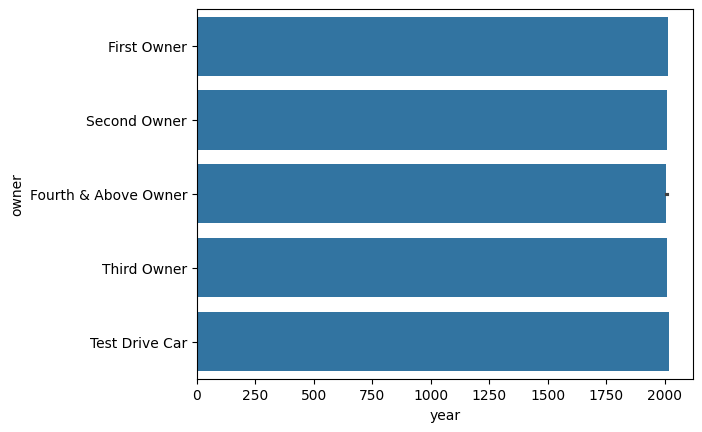

In [ ]:
sns.barplot(data=df_neat,x='year',y='owner')

<Axes: xlabel='selling_price', ylabel='seller_type'>

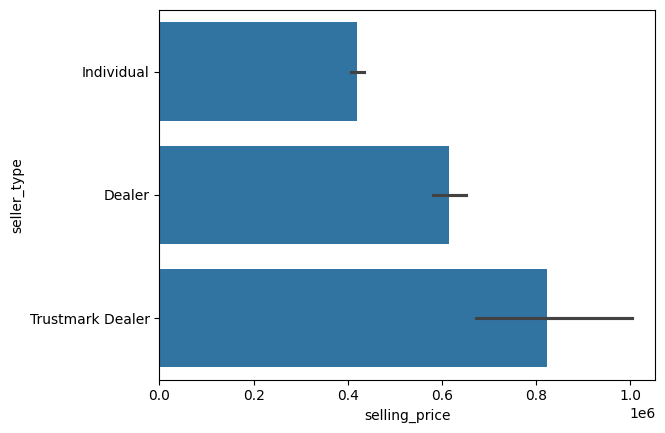

In [ ]:
sns.barplot(data=df_neat,x='selling_price',y='seller_type')

<Axes: xlabel='selling_price', ylabel='owner'>

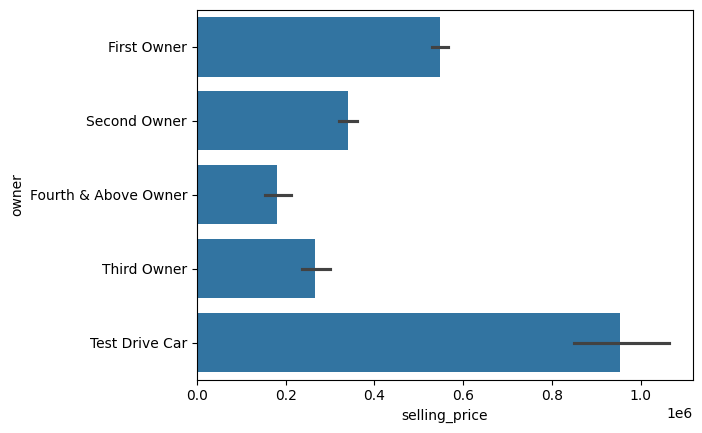

In [ ]:
sns.barplot(data=df_neat,x='selling_price',y='owner')

<Axes: xlabel='selling_price', ylabel='fuel'>

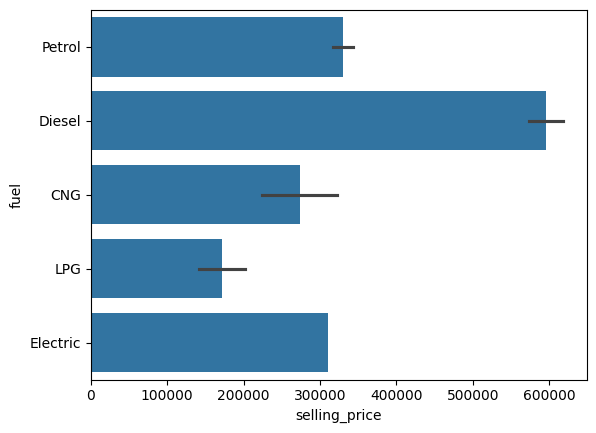

In [ ]:
sns.barplot(data=df_neat,x='selling_price',y='fuel')

<Axes: xlabel='selling_price', ylabel='transmission'>

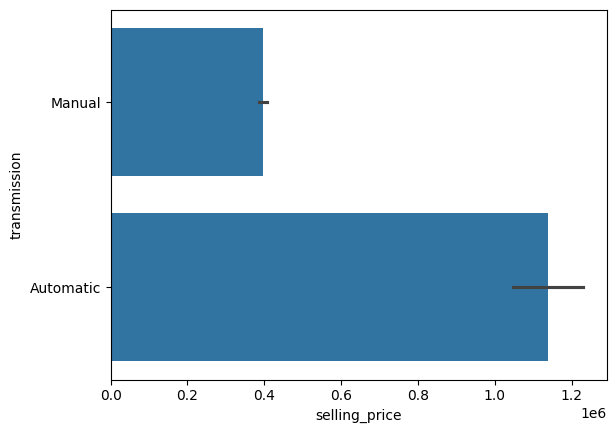

In [ ]:
sns.barplot(data=df_neat,x='selling_price',y='transmission')

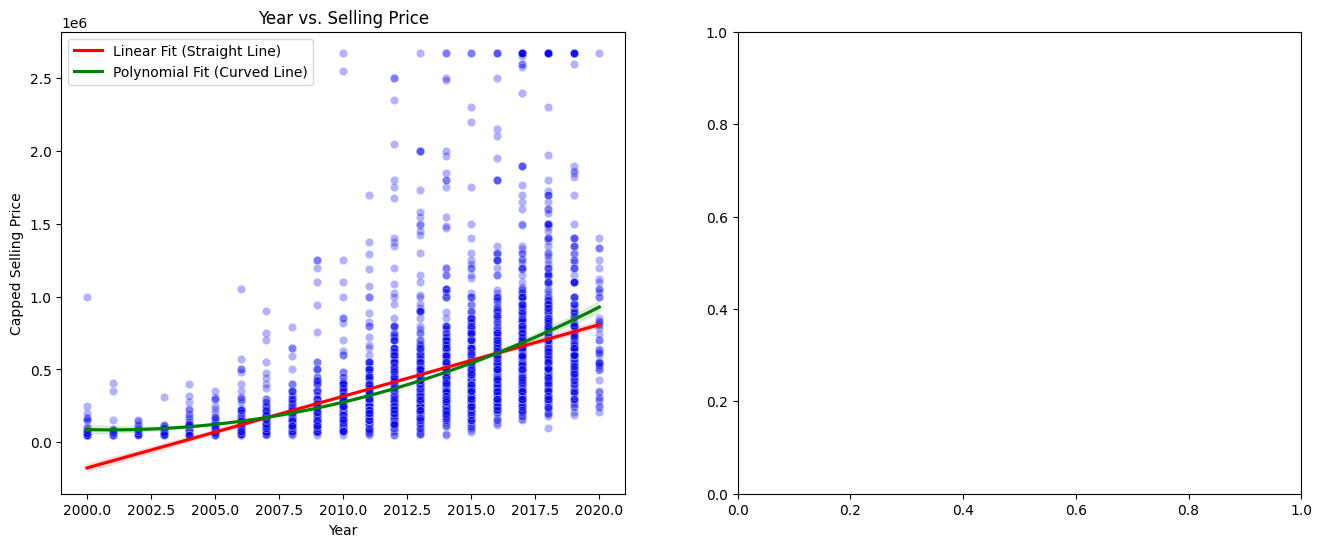

In [ ]:
fig, axes = plt.subplots(1,2,  figsize=(16, 6))

# --- Plot 1: Year vs Selling Price ---
# We use regplot to plot the raw scatter points
sns.scatterplot(ax=axes[0], data=df_neat, x='year', y='selling_price', color='blue', alpha=0.3)

# 1. Fit a straight LINEAR line (order=1)
sns.regplot(ax=axes[0], data=df_neat, x='year', y='selling_price', scatter=False,
            order=1, color='red', label='Linear Fit (Straight Line)')

# 2. Fit a curved POLYNOMIAL line (order=2)
sns.regplot(ax=axes[0], data=df_neat, x='year', y='selling_price', scatter=False,
            order=2, color='green', label='Polynomial Fit (Curved Line)')

axes[0].set_title('Year vs. Selling Price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Capped Selling Price')
axes[0].legend()

`feature engineering `
- transform
  - ordinal encoding

      - owner
  - one hot encoding
      - transmission
      - fuel
      - seller type
      - name

      
- standarize
  - year
  - km_driven
        

In [22]:

# --- 1. Ordinal Encoding ('owner') ---
ord_enc = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}
df_neat['owner'] = df_neat['owner'].map(ord_enc)

# --- 2. Feature Extraction ('name' -> 'brand') ---
# Extract brand to avoid high-cardinality one-hot encoding
df_neat['brand'] = df_neat['name'].str.split().str[0]
df_neat.drop(columns=['name'], inplace=True)

# --- 3. One-Hot Encoding ---
ohe_cols = ['transmission', 'fuel', 'seller_type', 'brand']
df_neat = pd.get_dummies(df_neat, columns=ohe_cols, dtype=float, drop_first=True)

# `model implementation`

In [23]:
# Separate Features and Target
X = df_neat.drop(columns=['selling_price'])
y = df_neat['selling_price']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify feature types
num_cols = ['year', 'km_driven']
cat_cols = [col for col in X_train.columns if col not in num_cols]

# Scale Numerical Features (Train set ONLY to prevent leakage)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

In [24]:
# Reconstruct baseline scaled datasets
X_train_scaled = np.hstack([X_train_num_scaled, X_train[cat_cols].values])
X_test_scaled = np.hstack([X_test_num_scaled, X_test[cat_cols].values])

# Fit Baseline Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Evaluate Baseline
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- Linear Regression Baseline ---")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lr):,.2f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_pred_lr):,.2f}")

--- Linear Regression Baseline ---
R² Score: 0.6746
MAE: $158,387.83
RMSE: $234,898.44


In [26]:
from sklearn.linear_model import LinearRegression, RidgeCV
# 1. Apply Polynomial Features on SCALED numerical data
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_num = poly.fit_transform(X_train_num_scaled)
X_test_poly_num = poly.transform(X_test_num_scaled)

# 2. Combine Polynomial numerical features with Categorical features
X_train_poly_final = np.hstack([X_train_poly_num, X_train[cat_cols].values])
X_test_poly_final = np.hstack([X_test_poly_num, X_test[cat_cols].values])

# 3. Optimize Regularization Strength with RidgeCV
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0], cv=5)
ridge_cv.fit(X_train_poly_final, y_train)

# 4. Predict & Evaluate
y_train_pred_ridge = ridge_cv.predict(X_train_poly_final)
y_test_pred_ridge = ridge_cv.predict(X_test_poly_final)

print("\n--- Polynomial (Degree 2) + Ridge Results ---")
print(f"Best Alpha Chosen: {ridge_cv.alpha_}")
print(f"Train R²: {r2_score(y_train, y_train_pred_ridge):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_ridge):.4f}")


--- Polynomial (Degree 2) + Ridge Results ---
Best Alpha Chosen: 0.1
Train R²: 0.7330
Test R²: 0.6979
